In [1]:
from keras.datasets import imdb

(training_data, training_targets), (testing_data, testing_targets) = imdb.load_data(num_words=10000)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [2]:
index = imdb.get_word_index()

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step


In [3]:
index

{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

In [4]:
inverted_word_index = dict((i, word) for (word, i) in index.items())
decoded_sequence = " ".join(inverted_word_index[i] for i in training_data[0])


In [5]:
from keras.preprocessing.sequence import pad_sequences

maxlen = 200
X_train = pad_sequences(training_data, maxlen=maxlen)
X_test = pad_sequences(testing_data, maxlen=maxlen)


In [6]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(training_targets,num_classes = 2)
y_test = testing_targets


In [8]:

import numpy as np

X_train_new = np.expand_dims(X_train, axis=2)
X_test_new = np.expand_dims(X_test, axis=2)


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, Dense

# Hàm mất mát, tối ưu hóa, và one-hot encoding
from tensorflow.keras.losses import BinaryCrossentropy, CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import numpy as np

In [13]:
model = Sequential()
model.add(Input(shape=(None, 1), dtype="float64"))
model.add(SimpleRNN(200, return_sequences=False, return_state=False, activation='relu'))
model.add(Dense(2, activation='sigmoid'))

optimizer = Adam(learning_rate=0.01)
loss = BinaryCrossentropy()

model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 200)            │        40,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           402 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,802 (159.38 KB)

 Trainable params: 40,802 (159.38 KB)

 Non-trainable params: 0 (0.00 B)

# Bài 1: Tăng số lượng epoch lên 20 và thực hiện huấn luyện mô hình. Cho biết độ chính xác của mô hình là bao nhiêu? Vẽ đồ thị học.

In [15]:
history = model.fit(
    X_train_new, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test_new, to_categorical(y_test, num_classes=2))
)


Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.4920 - loss: 35.0735 - val_accuracy: 0.4937 - val_loss: 0.9687
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.5124 - loss: 0.8610 - val_accuracy: 0.5058 - val_loss: 0.7071
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.5061 - loss: 0.7268 - val_accuracy: 0.5047 - val_loss: 0.7051
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.5021 - loss: 0.7012 - val_accuracy: 0.5002 - val_loss: 0.6955
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.5029 - loss: 0.6957 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.5017 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.4913 - loss: 0.6936 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.5033 - loss: 0.6933 - va

In [16]:
loss, accuracy = model.evaluate(X_test_new, to_categorical(y_test, num_classes=2))
print(f"Độ chính xác của mô hình trên tập test: {accuracy * 100:.2f}%")


782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5073 - loss: 0.6931
Độ chính xác của mô hình trên tập test: 50.00%


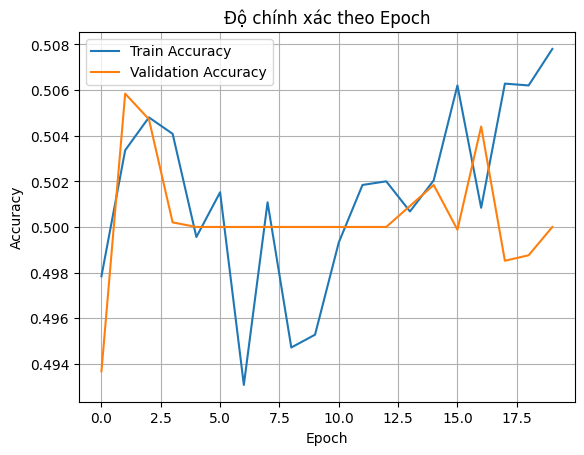

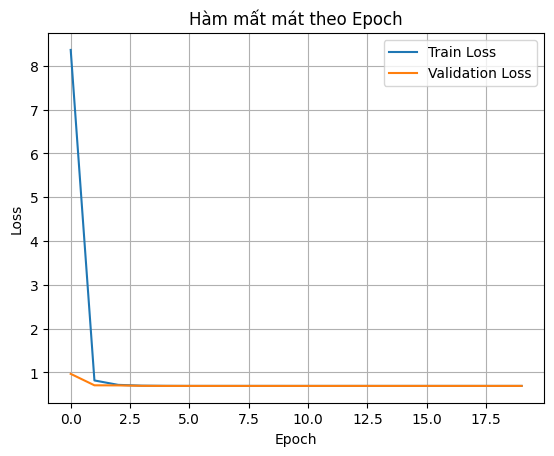

In [17]:
import matplotlib.pyplot as plt

# Độ chính xác
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Độ chính xác theo Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Hàm mất mát
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Hàm mất mát theo Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


# Bài 2

In [19]:
model = Sequential()
model.add(Input(shape=(None, 1), dtype="float64"))
model.add(SimpleRNN(200, return_sequences=True, return_state=False, activation='relu'))
model.add(SimpleRNN(200, return_sequences=False, return_state=False, activation='relu'))
model.add(Dense(2, activation='sigmoid'))

optimizer = Adam(learning_rate=0.01)
loss = BinaryCrossentropy()

model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])


In [20]:
history = model.fit(
    X_train_new, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test_new, to_categorical(y_test, num_classes=2))
)


Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step - accuracy: 0.4961 - loss: 35.7646 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - accuracy: 0.5032 - loss: 0.6935 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.4984 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.4974 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.5021 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.4952 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.5090 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.5038 - loss: 0.6933 -

In [21]:
loss, accuracy = model.evaluate(X_test_new, to_categorical(y_test, num_classes=2))
print(f"Độ chính xác của mô hình trên tập test: {accuracy * 100:.2f}%")


782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.5073 - loss: 0.6930
Độ chính xác của mô hình trên tập test: 50.00%


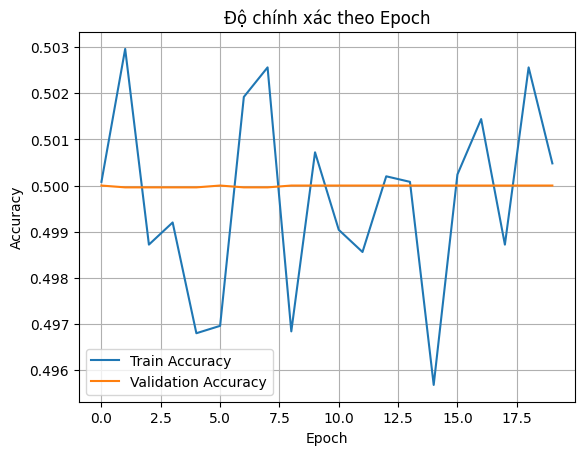

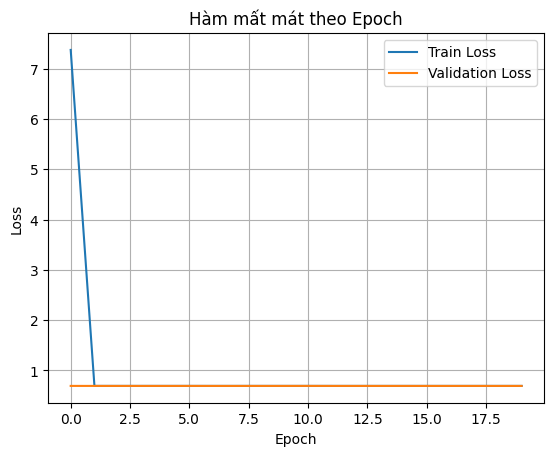

In [22]:
import matplotlib.pyplot as plt

# Độ chính xác
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Độ chính xác theo Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Hàm mất mát
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Hàm mất mát theo Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


# Bài 3

In [33]:
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import numpy as np

num_words = 10000
maxlen = 200

(training_data, training_targets), (testing_data, testing_targets) = imdb.load_data(num_words=num_words)
X_train = pad_sequences(training_data, maxlen=maxlen)
X_test = pad_sequences(testing_data, maxlen=maxlen)


y_train = to_categorical(training_targets, num_classes=2)
y_test = to_categorical(testing_targets, num_classes=2)


In [34]:
model = Sequential()
model.add(Embedding(input_dim=num_words, output_dim=128, input_length=maxlen))  # ánh xạ chỉ số từ sang vector 128 chiều
model.add(LSTM(128, activation='tanh'))
model.add(Dense(2, activation='softmax'))


model.compile(optimizer=Adam(learning_rate=0.001), loss=CategoricalCrossentropy(), metrics=['accuracy'])

In [35]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [36]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test)
)


Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7142 - loss: 0.5227 - val_accuracy: 0.8552 - val_loss: 0.3453
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9047 - loss: 0.2407 - val_accuracy: 0.8655 - val_loss: 0.3189
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9344 - loss: 0.1759 - val_accuracy: 0.8590 - val_loss: 0.3484
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9578 - loss: 0.1172 - val_accuracy: 0.8561 - val_loss: 0.4114
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.9718 - loss: 0.0839 - val_accuracy: 0.8402 - val_loss: 0.4583
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9734 - loss: 0.0751 - val_accuracy: 0.8562 - val_loss: 0.5565
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9888 - loss: 0.0378 - val_accuracy: 0.8403 - val_loss: 0.6037
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9866 - loss: 0.0433 - val_a

In [38]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Độ chính xác của mô hình (Embedding + LSTM): {accuracy * 100:.2f}%")


782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8509 - loss: 0.9382
Độ chính xác của mô hình (Embedding + LSTM): 85.12%


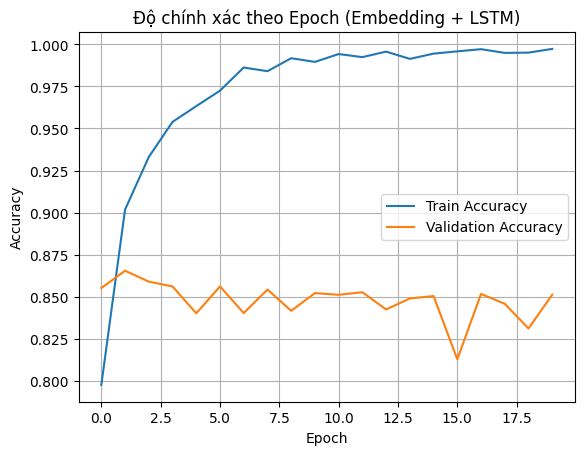

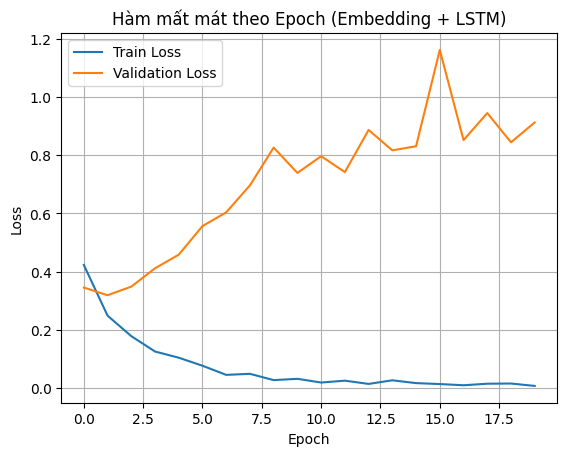

In [39]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Độ chính xác theo Epoch (Embedding + LSTM)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Hàm mất mát theo Epoch (Embedding + LSTM)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


# Bài 4: Xây dựng mô hình gồm 1 lớp Embedding và 2 lớp LSTM kết nối với nhau. Cho biết độ chính xác của mô hình là bao nhiêu? Vẽ đồ thị học.

In [40]:
model = Sequential()

# Lớp Embedding
model.add(Embedding(input_dim=num_words, output_dim=128, input_length=maxlen))

# Lớp LSTM đầu tiên
model.add(LSTM(128, return_sequences=True, activation='tanh'))

# Lớp LSTM thứ hai
model.add(LSTM(128, activation='tanh'))

model.add(Dense(2, activation='softmax'))

# Compile mô hình
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

model.compile(optimizer=Adam(learning_rate=0.001), loss=CategoricalCrossentropy(), metrics=['accuracy'])

In [41]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [42]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test)
)


Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.6963 - loss: 0.5450 - val_accuracy: 0.8580 - val_loss: 0.3365
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.8973 - loss: 0.2609 - val_accuracy: 0.8682 - val_loss: 0.3136
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.9338 - loss: 0.1757 - val_accuracy: 0.8583 - val_loss: 0.3529
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.9561 - loss: 0.1245 - val_accuracy: 0.8612 - val_loss: 0.3769
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.9612 - loss: 0.1086 - val_accuracy: 0.7156 - val_loss: 0.5516
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.8669 - loss: 0.3070 - val_accuracy: 0.8500 - val_loss: 0.4871
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.9620 - loss: 0.1060 - val_accuracy: 0.8471 - val_loss: 0.4507
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.9843 - loss: 0.0502 - 

In [43]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Độ chính xác của mô hình (Embedding + 2 LSTM): {accuracy * 100:.2f}%")


782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8465 - loss: 1.0590
Độ chính xác của mô hình (Embedding + 2 LSTM): 84.68%


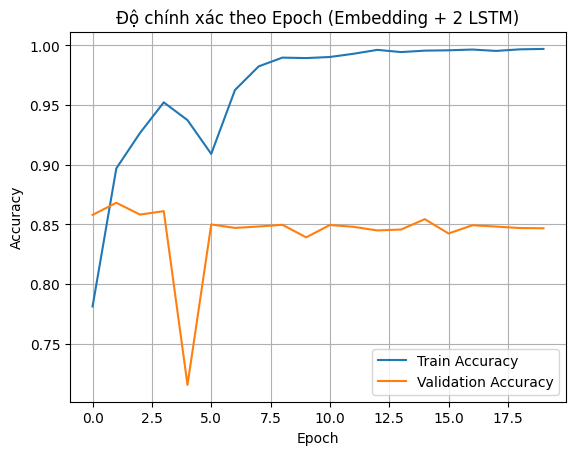

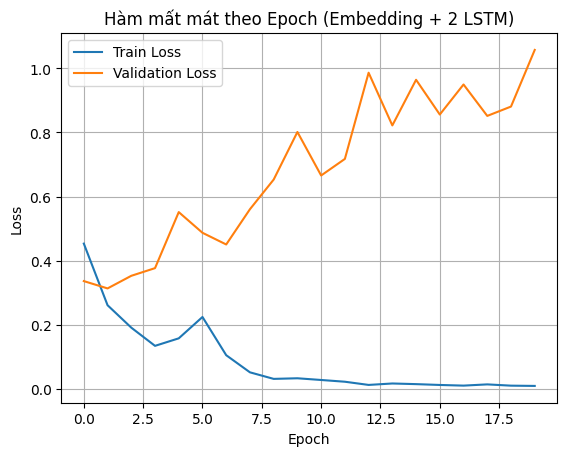

In [44]:
import matplotlib.pyplot as plt

# Độ chính xác
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Độ chính xác theo Epoch (Embedding + 2 LSTM)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Hàm mất mát
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Hàm mất mát theo Epoch (Embedding + 2 LSTM)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


# Bài 5

In [46]:
from tensorflow.keras.layers import Embedding, GRU, Dense

In [51]:
model = Sequential()

# Lớp Embedding
model.add(Embedding(input_dim=num_words, output_dim=128, input_length=maxlen))

# Lớp GRU duy nhất
model.add(GRU(128, activation='tanh'))  # Chỉ sử dụng 1 lớp GRU

# Lớp Dense để phân loại nhị phân
model.add(Dense(2, activation='softmax'))  # softmax vì chúng ta dùng to_categorical cho nhãn

# Compile mô hình
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

model.compile(optimizer=Adam(learning_rate=0.001), loss=CategoricalCrossentropy(), metrics=['accuracy'])

In [52]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test)
)


Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.6883 - loss: 0.5687 - val_accuracy: 0.8589 - val_loss: 0.3294
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8953 - loss: 0.2589 - val_accuracy: 0.8696 - val_loss: 0.3193
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9401 - loss: 0.1613 - val_accuracy: 0.8753 - val_loss: 0.3219
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9612 - loss: 0.1115 - val_accuracy: 0.8668 - val_loss: 0.3464
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9784 - loss: 0.0679 - val_accuracy: 0.8515 - val_loss: 0.4699
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9868 - loss: 0.0421 - val_accuracy: 0.8621 - val_loss: 0.5535
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9914 - loss: 0.0275 - val_accuracy: 0.8615 - val_loss: 0.6813
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9938 - loss: 0.0208 - val_ac

In [55]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Độ chính xác của mô hình (Embedding + 1 GRU): {accuracy * 100:.2f}%")


782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8593 - loss: 1.2092
Độ chính xác của mô hình (Embedding + 1 GRU): 85.90%


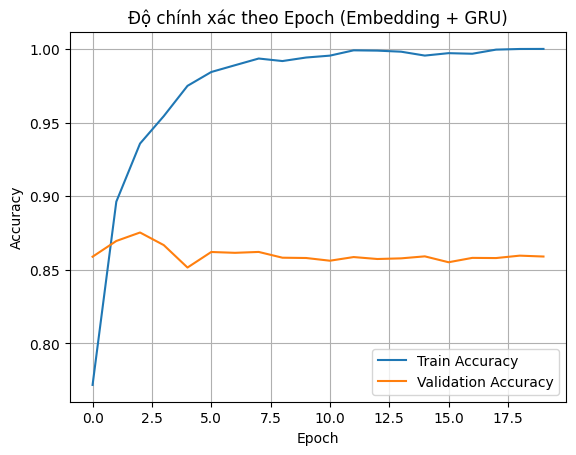

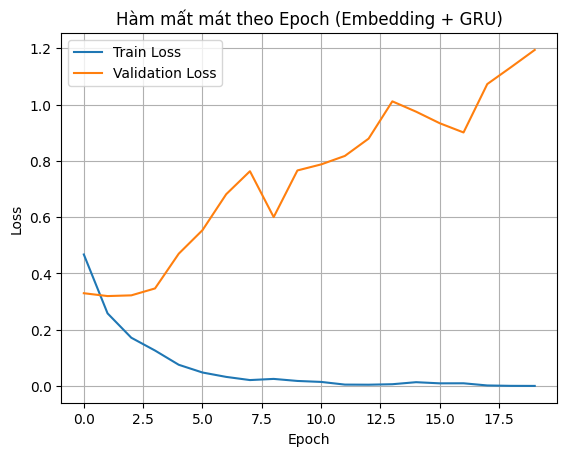

In [56]:
import matplotlib.pyplot as plt

# Độ chính xác
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Độ chính xác theo Epoch (Embedding + GRU)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Hàm mất mát
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Hàm mất mát theo Epoch (Embedding + GRU)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()
